Paquetes necesarios

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

TAREA: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

Hay 7 filas con un número de píxeles blancos mayor o igual que 0.90*maxfil y estas son sus posiciones: [6, 12, 15, 20, 21, 88, 100]


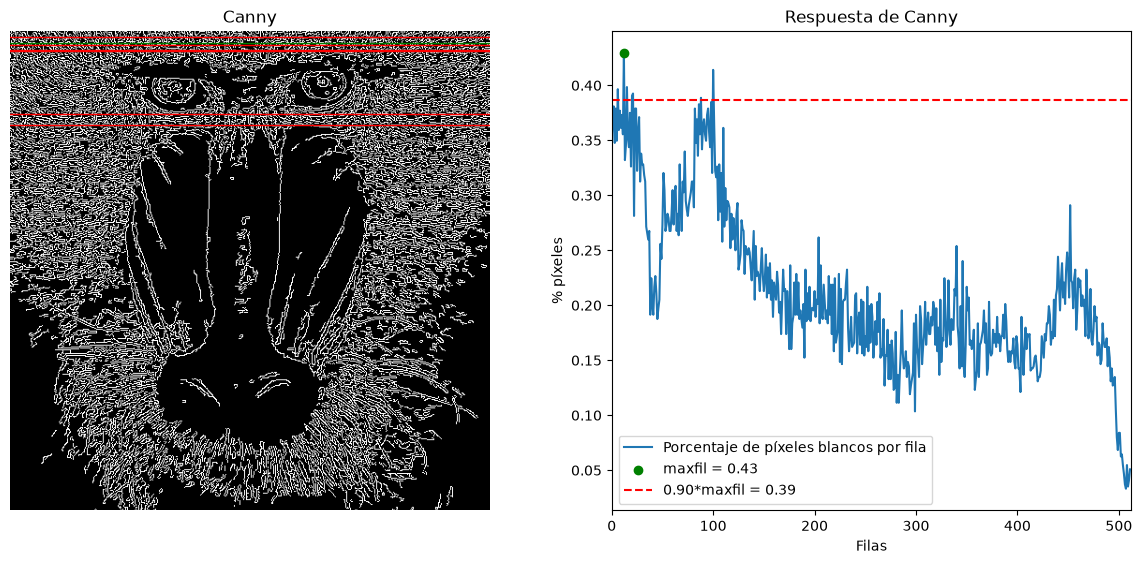

In [2]:
# Leemos la imagen del archivo
img = cv2.imread('images/mandril.jpg')

# Si hay lectura correcta
if img is not None:
    # Conversión de la imagen a niveles de grises de la imagen original en BGR
    gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Obtenemos los contornos con el operador de Canny
    canny = cv2.Canny(gris, 100, 200)

    # Contamos el número de píxeles blancos (255) por fila
    # Sumamos los valores de los pixeles por fila
    row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
    row_counts = row_counts.flatten()  # Aplanamos el array para que sea unidimensional

    # Normalizamos en base al número de columnas, segundo valor devuelto por shape, y al valor máximo del píxel (255)
    # El resultado será el número de píxeles blancos por fila
    rows = row_counts / (255 * canny.shape[1])

    # Obtenemos el valor máximo de píxeles blancos para filas
    maxfil = rows.max()

    # Obtenemos el índice de la fila con el máximo número de píxeles blancos
    idx_maxfil = np.where(rows == maxfil)[0][0]  

    # Creamos una lista para almacenar los índices de las filas que cumplen el umbral
    idx_rows_threshold = []

    # Mostramos dicha cuenta gráficamente
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.axis("off")
    plt.title("Canny")
    for i in range(len(rows)):
        if rows[i] >= maxfil*0.9:
            idx_rows_threshold.append(i)                                 # Añadimos el índice de la fila que cumple el umbral a la lista

            if i == idx_maxfil: 
                plt.axhline(y=i, color='g', linestyle='-', linewidth=1)  # Mostramos la fila con el máximo número de píxeles blancos
            else:
                plt.axhline(y=i, color='r', linestyle='-', linewidth=1)  # Mostramos las filas que superan el 90% del valor máximo
    plt.imshow(canny, cmap='gray')

    # Calculamos el umbral como el 90% del valor máximo de píxeles blancos por fila
    umbral = maxfil * 0.9  

    plt.subplot(1, 2, 2)
    plt.title("Respuesta de Canny")
    plt.xlabel("Filas")
    plt.ylabel("% píxeles")
    plt.plot(rows, label='Porcentaje de píxeles blancos por fila')
    plt.scatter(idx_maxfil, maxfil, color='g', zorder=5, label=f'maxfil = {maxfil:.2f}')  # Marcamos el máximo con un punto verde
    plt.axhline(y=umbral, color='r', linestyle='--', label=f'0.90*maxfil = {umbral:.2f}')  # Línea horizontal para el umbral
    # Rango en x definido por las filas
    plt.xlim([0, canny.shape[0]])
    plt.legend()
    plt.tight_layout(pad=2.0, w_pad=3.0) # Ajustamos el espaciado entre subplots

    print(f"Hay {len(idx_rows_threshold)} filas con un número de píxeles blancos mayor o igual que 0.90*maxfil y estas son sus posiciones: {idx_rows_threshold}")

else: 
    print('Imagen no encontrada')

TAREA: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

In [3]:
# Funciones auxiliares para el cálculo de filas y columnas, resaltado y graficado

def get_rows_columns(image):
    # Contamos el número de píxeles blancos (255) por fila
    # Sumamos los valores de los pixeles por fila
    row_counts = cv2.reduce(image, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

    # Contamos el número de píxeles blancos (255) por columna
    # Sumamos los valores de los pixeles por columna
    col_counts = cv2.reduce(image, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

    # Normalizamos en base al número de columnas, segundo valor devuelto por shape, y al valor máximo del píxel (255)
    # El resultado será el número de píxeles blancos por fila
    rows = row_counts[:, 0] / (255 * image.shape[1])

    # Normalizamos en base al número de filas, primer valor devuelto por shape, y al valor máximo del píxel (255)
    # El resultado será el número de píxeles blancos por columna
    cols = col_counts[0, :] / (255 * image.shape[0])

    return rows, cols

def highlight_rows_columns(image, rows, cols, row_color=(0, 0, 255), col_color=(255, 0, 0), max_color=(0, 255, 0)):
    # Convertimos la imagen a BGR para poder dibujar en color
    image_bgr = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    # Obtenemos el valor máximo de píxeles blancos para filas y columnas
    maxfil = np.max(rows)
    maxcol = np.max(cols)

    # Obtenemos el índice de la fila y columna con el valor máximo de píxeles blancos
    idx_maxfil = np.argmax(rows)
    idx_maxcol = np.argmax(cols)

    # Buscamos y resaltamos las filas con un número de píxeles blancos mayor o igual que 0.90*maxfil
    idx_rows = []
    for i in range(0, len(rows)):
        if rows[i] >= (0.90 * maxfil):
            idx_rows.append(i)

            # Si la fila es la que tiene el máximo número de píxeles blancos, la resaltamos en verde, si no, en rojo
            if i == idx_maxfil:
                cv2.line(image_bgr, (0, i), (image_bgr.shape[1], i), max_color, 1)
            else:
                cv2.line(image_bgr, (0, i), (image_bgr.shape[1], i), row_color, 1)

    # Buscamos y resaltamos las columnas con un número de píxeles blancos mayor o igual que 0.90*maxcol
    idx_cols = []
    for i in range(0, len(cols)):
        if cols[i] >= (0.90 * maxcol):
            idx_cols.append(i)

            # Si la columna es la que tiene el máximo número de píxeles blancos, la resaltamos en verde, si no, en azul
            if i == idx_maxcol:
                cv2.line(image_bgr, (i, 0), (i, image_bgr.shape[0]), max_color, 1)
            else:
                cv2.line(image_bgr, (i, 0), (i, image_bgr.shape[0]), col_color, 1)

    return image_bgr, idx_rows, idx_cols

def plot_results(image_bgr, rows, cols, title):
    # Calculamos los valores máximos, sus índices y los umbrales de filas y columnas para construir las gráficas
    maxfil = np.max(rows)
    idx_maxfil = np.argmax(rows)
    umbral_fil = 0.90 * maxfil

    maxcol = np.max(cols)
    idx_maxcol = np.argmax(cols)
    umbral_col = 0.90 * maxcol
    
    # Mostramos el resultado y las cuentas gráficamente
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.axis("off")
    plt.title(f"Imagen: {title}")
    plt.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB), cmap='gray') 

    plt.subplot(1, 3, 2)
    plt.title(f"Filas - {title}")
    plt.xlabel("Filas")
    plt.ylabel("% píxeles")
    plt.plot(rows)
    plt.scatter(idx_maxfil, maxfil, color='g', zorder=5)  # Marcamos el máximo con un punto verde
    plt.axhline(y=umbral_fil, color='r', linestyle='--')  # Línea horizontal para el umbral
    # Rango en x definido por el número de filas de la imagen
    plt.xlim([0, image_bgr.shape[0]])

    plt.subplot(1, 3, 3)
    plt.title(f"Columnas - {title}")
    plt.xlabel("Columnas")
    plt.ylabel("% píxeles")
    plt.plot(cols)
    plt.scatter(idx_maxcol, maxcol, color='g', zorder=5)  # Marcamos el máximo con un punto verde
    plt.axhline(y=umbral_col, color='r', linestyle='--')  # Línea horizontal para el umbral
    # Rango en x definido por el número de columnas de la imagen
    plt.xlim([0, image_bgr.shape[1]])

    plt.tight_layout(pad=3.0, w_pad=4.0) # Separación entre plots
    plt.show()

[Canny] Hay 7 filas con un número de píxeles blancos mayor o igual que 0.90*maxfil y estas son sus posiciones: [6, 12, 15, 20, 21, 88, 100]
[Canny] Hay 19 columnas con un número de píxeles blancos mayor o igual que 0.90*maxcol y estas son sus posiciones: [67, 86, 92, 96, 99, 100, 103, 104, 105, 112, 115, 119, 123, 379, 380, 383, 392, 396, 403]


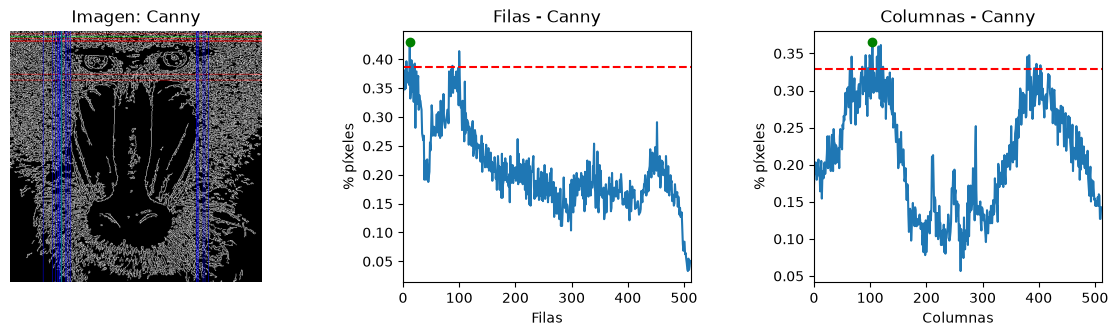

[Sobel Umbralizado] Hay 9 filas con un número de píxeles blancos mayor o igual que 0.90*maxfil y estas son sus posiciones: [3, 4, 8, 20, 51, 81, 82, 83, 87]
[Sobel Umbralizado] Hay 3 columnas con un número de píxeles blancos mayor o igual que 0.90*maxcol y estas son sus posiciones: [104, 127, 288]


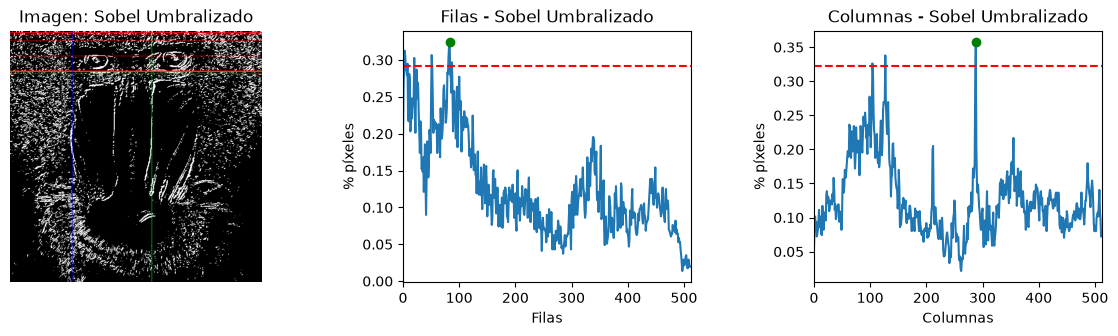

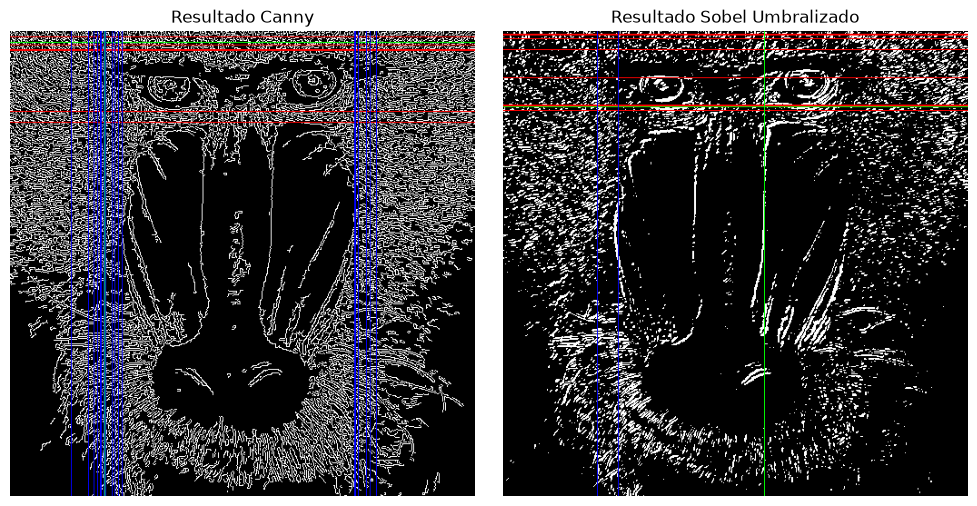

In [4]:
# Leemos la imagen del archivo
img = cv2.imread('images/mandril.jpg') 

# Si hay lectura correcta
if img is not None:
    # Conversión de la imagen a niveles de grises de la imagen original en BGR
    gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # --- PROCESO DE CANNY ---

    # Obtenemos los contornos con el operador de Canny
    # Parámetros: imagen de entrada, umbral inferior, umbral superior
    canny = cv2.Canny(gris, 100, 200)

    # Calculamos los píxeles blancos por fila/columna y resaltamos las filas/columnas que cumplen el umbral
    rows_canny, cols_canny = get_rows_columns(canny)
    canny_bgr, idx_rows_canny, idx_cols_canny = highlight_rows_columns(canny, rows_canny, cols_canny)

    print(f"[Canny] Hay {len(idx_rows_canny)} filas con un número de píxeles blancos mayor o igual que 0.90*maxfil y estas son sus posiciones: {idx_rows_canny}")
    print(f"[Canny] Hay {len(idx_cols_canny)} columnas con un número de píxeles blancos mayor o igual que 0.90*maxcol y estas son sus posiciones: {idx_cols_canny}")

    # Mostramos las gráficas para Canny
    plot_results(canny_bgr, rows_canny, cols_canny, "Canny")

    # --- PROCESO DE SOBEL ---

    # Gaussiana para suavizar la imagen original, eliminando altas frecuencias
    ggris = cv2.GaussianBlur(gris, (3, 3), 0)

    # Calcula en ambas direcciones (horizontal y vertical)
    sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # x
    sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # y

    # Combina ambos resultados
    sobel = cv2.add(sobelx, sobely)

    # Conversión a byte con openCV
    sobel8 = cv2.convertScaleAbs(sobel)

    # Definimos el valor del umbral
    valorUmbral = 127
    
    # Obtenemos la imagen sobel8 umbralizada para dicho valor definido
    _, imagenSobelUmbralizada = cv2.threshold(sobel8, valorUmbral, 255, cv2.THRESH_BINARY)

    # Calculamos los píxeles blancos por fila/columna y resaltamos las filas/columnas que cumplen el umbral
    rows_sobel, cols_sobel = get_rows_columns(imagenSobelUmbralizada)
    sobel_bgr, idx_rows_sobel, idx_cols_sobel = highlight_rows_columns(imagenSobelUmbralizada, rows_sobel, cols_sobel)

    print(f"[Sobel Umbralizado] Hay {len(idx_rows_sobel)} filas con un número de píxeles blancos mayor o igual que 0.90*maxfil y estas son sus posiciones: {idx_rows_sobel}")
    print(f"[Sobel Umbralizado] Hay {len(idx_cols_sobel)} columnas con un número de píxeles blancos mayor o igual que 0.90*maxcol y estas son sus posiciones: {idx_cols_sobel}")

    # Mostramos las gráficas para Sobel Umbralizado
    plot_results(sobel_bgr, rows_sobel, cols_sobel, "Sobel Umbralizado")

    # --- COMPARATIVA FINAL ---

    # Mostramos la comparación de la imagen de Canny y la imagen de Sobel Umbralizada
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.axis("off")
    plt.title("Resultado Canny")
    plt.imshow(cv2.cvtColor(canny_bgr, cv2.COLOR_BGR2RGB)) 

    plt.subplot(1, 2, 2)
    plt.axis("off")
    plt.title("Resultado Sobel Umbralizado")
    plt.imshow(cv2.cvtColor(sobel_bgr, cv2.COLOR_BGR2RGB))
    plt.tight_layout() 
    plt.show()

else:
    print('Imagen no encontrada')


TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.